In [1]:
!pip install wfdb -q
!pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 86.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


In [2]:
import wfdb

import random
import pickle
from enum import Enum

import os
from google.colab import drive

import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

import matplotlib.pyplot as plt

In [3]:
# patient_list = wfdb.get_record_list('mitdb')
# patient_list = [patient for patient in patient_list if patient not in ['102','104','114']]
# print(f"Total number of records : {len(patient_list)}")

# test_records = random.sample(patient_list,9)
# print(f"Number of test records :{len(test_records)}, test_records = {test_records}")

# train_records = [patient for patient in patient_list if patient not in test_records]
# print(f"Number of train records :{len(train_records)}, train_records = {train_records}")

In [5]:
TRAIN_RECORDS = ['101', '103', '105', '106', '107', '109',
                 '111', '112', '113', '115', '116', '118',
                 '119', '122', '123', '124', '200', '201',
                 '203', '205', '207', '208', '209', '210',
                 '212', '213', '214', '215', '219', '220',
                 '223', '228', '230', '231', '232', '234'] # 36 patient (80%)

TEST_RECORDS = ['222', '202', '108', '100', '117', '221',
                '217', '121', '233'] # 9 patient (20%)


# ============================================================
# CONFIG
# ============================================================

WINDOW_SIZE = 2048
STEP_SIZE = 1024   # 50% overlap

SNR_LEVELS = [0, 5, 10]
# Later experiment with: SNR_LEVELS = [-6, 0, 5, 10]

SAVE_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/ECG_Denoising_Dataset"

N_ITERATIONS = 100

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

In [6]:
# ============================================================
# NOISE TYPE ENUM
# ============================================================

class ECGNoiseType(Enum):
    BW = 1
    MA = 2
    BOTH = 3

In [7]:
def normalize_signal(signal):
    # standardization
    signal = signal - np.mean(signal)
    signal = signal / (np.std(signal) + 1e-8)
    # scaling [-1,1] to match tanh output
    signal = signal / np.max(np.abs(signal))
    return signal

def load_ecg_record(record_name):
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')
    signal = record.p_signal[:, 0] # MLII
    signal = normalize_signal(signal)
    return signal

def load_noise_signals():
    print("Loading BW noise...")
    bw_record = wfdb.rdrecord('bw', pn_dir='nstdb')
    bw_noise = bw_record.p_signal[:, 0]

    print("Loading MA noise...")
    ma_record = wfdb.rdrecord('ma', pn_dir='nstdb')
    ma_noise = ma_record.p_signal[:, 0]

    bw_noise = normalize_signal(bw_noise)
    ma_noise = normalize_signal(ma_noise)

    return bw_noise, ma_noise

# def segment(signal, window=2048, step=1024):
#     segments = []
#     for i in range(0, len(signal) - window, step):
#         segments.append(signal[i:i+window])
#     return np.array(segments)

In [8]:
def segment_signal(signal,
                   record_name,
                   window=WINDOW_SIZE,
                   step=STEP_SIZE):

    segments = []

    metadata = []

    seg_idx = 0

    for start in range(0, len(signal) - window, step):

        end = start + window

        seg = signal[start:end]

        segments.append(seg)

        metadata.append({

            'record': record_name,

            'segment_idx': seg_idx,

            'start': start,

            'end': end
        })

        seg_idx += 1

    return np.array(segments), metadata

In [9]:
def add_noise_snr(clean, noise, target_snr_db):

    # Ensure same length
    noise = noise[:len(clean)]
    # noise_start_idx = np.random.randint(0, len(noise)-len(clean))
    # noise = noise[noise_start_idx:noise_start_idx+len(clean)]

    # Signal power
    signal_power = np.mean(clean ** 2)

    # Noise power
    noise_power = np.mean(noise ** 2)

    # Convert SNR from dB
    target_snr_linear = 10 ** (target_snr_db / 10)

    # Required noise power
    required_noise_power = signal_power / target_snr_linear

    # Scale factor
    scale = np.sqrt(required_noise_power / noise_power)

    # Scale noise
    scaled_noise = noise * scale

    # Create noisy ECG
    noisy = clean + scaled_noise

    return noisy

In [10]:
# ============================================================
# CALCULATE ACTUAL SNR
# ============================================================

def calculate_snr(clean,
                  noisy):

    noise = noisy - clean

    signal_power = np.mean(clean ** 2)

    noise_power = np.mean(noise ** 2)

    snr = 10 * np.log10(
        signal_power / noise_power
    )

    return snr

In [11]:
# def generate_noisy_ecg_1(clean_segment,
#                        bw_noise,
#                        ma_noise,
#                        target_snr_levels= SNR_LEVELS):



#     ############################################
#     # bw_segments = segment(bw_noise)
#     # ma_segments = segment(ma_noise)

#     # bw_idx = np.random.randint(0, len(bw_segments))
#     # ma_idx = np.random.randint(0, len(ma_segments))

#     # # randomly choose noise type
#     # if np.random.rand() > 0.5:
#     #     noise = bw_segments[bw_idx]
#     # else:
#     #     noise = ma_segments[ma_idx]
#     ############################################


#     ############################################
#     seg_len = len(clean_segment)

#     # Random positions
#     bw_start = np.random.randint(0, len(bw_noise) - seg_len)
#     ma_start = np.random.randint(0, len(ma_noise) - seg_len)

#     bw_seg = bw_noise[bw_start:bw_start+seg_len]
#     ma_seg = ma_noise[ma_start:ma_start+seg_len]



#     # randomly choose noise type
#     if np.random.rand() > 0.5:
#         noise = bw_seg
#         segment_noise_type = ECGNoiseType.BW
#     else:
#         noise = ma_seg
#         segment_noise_type = ECGNoiseType.MA

#     ############################################

#     # Choose randomly the snr
#     target_snr_db = random.choice(target_snr_levels)

#     # Add noise with target SNR
#     noisy = add_noise_snr(
#         clean_segment,
#         noise,
#         target_snr_db
#     )

#     # Normalize final signal to [-1,1]
#     noisy = noisy / np.max(np.abs(noisy))

#     # return noisy
#     return noisy,target_snr_db,segment_noise_type


In [12]:
# def generate_noisy_ecg_2(clean_segment,
#                        bw_noise,
#                        ma_noise,
#                        target_snr_levels= SNR_LEVELS):


#     seg_len = len(clean_segment)

#     # Random positions
#     bw_start = np.random.randint(0, len(bw_noise) - seg_len)
#     ma_start = np.random.randint(0, len(ma_noise) - seg_len)

#     bw_seg = bw_noise[bw_start:bw_start+seg_len]
#     ma_seg = ma_noise[ma_start:ma_start+seg_len]

#     # Random mixing weights
#     bw_weight = np.random.uniform(0.01, 0.5)
#     ma_weight = np.random.uniform(0.01, 0.5)


#     # Combine noises
#     # combined_noise = bw_seg + ma_seg
#     combined_noise = bw_weight * bw_seg + ma_weight * ma_seg

#     # Normalize Combine noises  to [-1,1]
#     combined_noise = combined_noise / np.max(np.abs(combined_noise))

#     # Choose randomly the snr
#     target_snr_db = random.choice(target_snr_levels)

#     # Add noise with target SNR
#     noisy = add_noise_snr(
#         clean_segment,
#         combined_noise,
#         target_snr_db
#     )

#     # Normalize final signal to [-1,1]
#     noisy = noisy / np.max(np.abs(noisy))
#     # return noisy

#     return noisy,target_snr_db,ECGNoiseType.BOTH

In [13]:
# ============================================================
# GENERATE NOISY ECG
# ============================================================

def generate_noisy_ecg(clean_segment,
                       bw_noise,
                       ma_noise,
                       target_snr_levels=SNR_LEVELS):

    seg_len = len(clean_segment)

    # Random positions
    bw_start = np.random.randint(
        0,
        len(bw_noise) - seg_len
    )

    ma_start = np.random.randint(
        0,
        len(ma_noise) - seg_len
    )

    bw_seg = bw_noise[
        bw_start:bw_start + seg_len
    ]

    ma_seg = ma_noise[
        ma_start:ma_start + seg_len
    ]

    # Random noise mode
    mode = np.random.choice([
        ECGNoiseType.BW,
        ECGNoiseType.MA
        # ,ECGNoiseType.BOTH
    ])

    if mode == ECGNoiseType.BW:
        noise = bw_seg

    else:
        #mode == ECGNoiseType.MA:
        noise = ma_seg


    # ## remove this option now
    # else:

    #     bw_weight = np.random.uniform(0.01, 0.5)

    #     ma_weight = np.random.uniform(0.01, 0.5)

    #     noise = (
    #         bw_weight * bw_seg +
    #         ma_weight * ma_seg
    #     )

    # Random SNR
    target_snr_db = random.choice(
        target_snr_levels
    )

    ######################################################
    # is normalization needed before & after noise addition
    # especially in case of adding both noise types
    #######################################################

    noisy = add_noise_snr(
        clean_segment,
        noise,
        target_snr_db
    )

    # Optional clipping
    noisy = np.clip(noisy, -1, 1)

    actual_snr = calculate_snr(
        clean_segment,
        noisy
    )

    return (
        noisy,
        target_snr_db,
        actual_snr,
        mode.name
    )

In [15]:
# def create_dataset(record_list,
#                    bw_noise,
#                    ma_noise):

#     clean_data = []
#     noisy_data = []
#     noise_added_data = []

#     for rec in tqdm(record_list):

#         print(f"\nProcessing Record: {rec}")

#         signal = load_ecg_record(rec)

#         segments = segment(signal)

#         for seg in segments:

#             noisy_seg,noise_snr,noise_type = generate_noisy_ecg_1(
#                 seg,
#                 bw_noise,
#                 ma_noise
#             )

#             clean_data.append(seg)
#             noisy_data.append(noisy_seg)
#             noise_added_data.append((noise_snr,noise_type))

#     clean_data = np.array(clean_data)
#     noisy_data = np.array(noisy_data)
#     noise_added_data = np.array(noise_added_data)

#     # Add channel dimension
#     clean_data = clean_data[:, np.newaxis, :]
#     noisy_data = noisy_data[:, np.newaxis, :]

#     # return noisy_data, clean_data
#     return noisy_data, clean_data, noise_added_data

In [16]:
# ============================================================
# CREATE DATASET
# ============================================================

def create_dataset(record_list,
                   bw_noise,
                   ma_noise):

    clean_data = []

    noisy_data = []

    metadata = []

    for rec in tqdm(record_list):

        print(f"\nProcessing Record: {rec}")

        signal = load_ecg_record(rec)

        segments, seg_metadata = segment_signal(
            signal,
            rec
        )

        for seg, meta in zip(
            segments,
            seg_metadata
        ):

            (
                noisy_seg,
                target_snr,
                actual_snr,
                noise_type
            ) = generate_noisy_ecg(
                seg,
                bw_noise,
                ma_noise
            )

            clean_data.append(seg)

            noisy_data.append(noisy_seg)

            # Add metadata
            meta['target_snr_db'] = target_snr

            meta['actual_snr_db'] = actual_snr

            meta['noise_type'] = noise_type

            metadata.append(meta)

    clean_data = np.array(clean_data)

    noisy_data = np.array(noisy_data)

    # Add channel dimension
    clean_data = clean_data[:, np.newaxis, :]

    noisy_data = noisy_data[:, np.newaxis, :]

    return noisy_data, clean_data, metadata

In [17]:
# ============================================================
# RECONSTRUCT FULL ECG FROM OVERLAPPING SEGMENTS
# ============================================================

def reconstruct_signal(segments,
                       window=WINDOW_SIZE,
                       step=STEP_SIZE):

    n_segments = len(segments)

    total_length = (
        step * (n_segments - 1)
        + window
    )

    reconstructed = np.zeros(total_length)

    counts = np.zeros(total_length)

    for i, seg in enumerate(segments):

        start = i * step

        end = start + window

        reconstructed[start:end] += seg

        counts[start:end] += 1

    reconstructed = reconstructed / counts

    return reconstructed

# ============================================================
# GET ALL SEGMENTS OF SPECIFIC PATIENT
# ============================================================

def get_patient_segments(data,
                         metadata,
                         patient_id):

    patient_segments = []

    for i, meta in enumerate(metadata):

        if meta['record'] == patient_id:

            patient_segments.append(
                data[i,0]
            )

    return np.array(patient_segments)

# ============================================================
# RECONSTRUCT FULL PATIENT ECG
# ============================================================

def reconstruct_patient_signal(data,
                               metadata,
                               patient_id):

    patient_segments = get_patient_segments(
        data,
        metadata,
        patient_id
    )

    full_signal = reconstruct_signal(
        patient_segments
    )

    return full_signal

# ============================================================
# VISUALIZE ECG
# ============================================================

def plot_ecg(clean=None,
             noisy=None,
             denoised=None,
             start=0,
             end=5000):

    plt.figure(figsize=(18,5))

    if clean is not None:

        plt.plot(
            clean[start:end],
            label='Clean',
            linewidth=2
        )

    if noisy is not None:

        plt.plot(
            noisy[start:end],
            label='Noisy',
            alpha=0.7
        )

    if denoised is not None:

        plt.plot(
            denoised[start:end],
            label='Denoised',
            alpha=0.8
        )

    plt.xlabel("Samples")

    plt.ylabel("Amplitude")

    plt.title("ECG Signal")

    plt.legend()

    plt.grid(True)

    plt.show()

In [18]:
def plot_segment(data,
                 metadata,
                 segment_index,
                 title="ECG Segment"):

    """
    Plot a specific ECG segment and print its metadata.

    Parameters
    ----------
    data : np.ndarray
        Shape: (N, 1, 2048)

    metadata : list
        Metadata list corresponding to segments

    segment_index : int
        Index of segment to visualize

    title : str
        Plot title
    """

    # Get segment
    segment = data[segment_index, 0]

    # Get metadata
    meta = metadata[segment_index]

    # =========================
    # Print Metadata
    # =========================

    print("=" * 50)

    print(f"Segment Index : {segment_index}")

    print(f"Patient Record: {meta['record']}")

    print(f"Segment ID    : {meta['segment_idx']}")

    print(f"Start Sample  : {meta['start']}")

    print(f"End Sample    : {meta['end']}")

    if 'noise_type' in meta:
        print(f"Noise Type    : {meta['noise_type']}")

    if 'target_snr_db' in meta:
        print(f"Target SNR    : {meta['target_snr_db']} dB")

    if 'actual_snr_db' in meta:
        print(f"Actual SNR    : {meta['actual_snr_db']:.2f} dB")

    print("=" * 50)

    # =========================
    # Plot
    # =========================

    plt.figure(figsize=(15,4))

    plt.plot(segment)

    plt.title(title)

    plt.xlabel("Samples")

    plt.ylabel("Amplitude")

    plt.grid(True)

    plt.show()


def compare_segment(clean_data,
                    noisy_data,
                    metadata,
                    segment_index):

    clean = clean_data[segment_index, 0]

    noisy = noisy_data[segment_index, 0]

    meta = metadata[segment_index]

    print("=" * 50)

    print(f"Patient Record: {meta['record']}")

    print(f"Noise Type   : {meta['noise_type']}")

    print(f"Target SNR   : {meta['target_snr_db']} dB")

    print(f"Actual SNR   : {meta['actual_snr_db']:.2f} dB")

    print("=" * 50)

    plt.figure(figsize=(18,5))

    plt.plot(clean,
             label='Clean',
             linewidth=2)

    plt.plot(noisy,
             label='Noisy',
             alpha=0.7)

    plt.title(
        f"Segment {segment_index}"
    )

    plt.xlabel("Samples")

    plt.ylabel("Amplitude")

    plt.legend()

    plt.grid(True)

    plt.show()

In [19]:
# ============================================================
# SAVE METADATA
# ============================================================

def save_metadata(metadata,
                  filepath):

    with open(filepath, 'wb') as f:

        pickle.dump(metadata, f)

# ============================================================
# LOAD METADATA
# ============================================================

def load_metadata(filepath):

    with open(filepath, 'rb') as f:

        metadata = pickle.load(f)

    return metadata

In [ ]:
# # =========================
# # LOAD NOISE
# # =========================

# bw_noise, ma_noise = load_noise_signals()

# # =========================
# # CREATE TRAIN DATASET
# # =========================

# print("\nCreating TRAIN dataset...")

# x_train, y_train, noise_train = create_dataset(
#     TRAIN_RECORDS,
#     bw_noise,
#     ma_noise
# )

# print("\nTrain Shapes:")
# print("x_train:", x_train.shape)
# print("y_train:", y_train.shape)
# print("noise_train:", noise_train.shape)

# # =========================
# # CREATE TEST DATASET
# # =========================

# print("\nCreating TEST dataset...")

# x_test, y_test, noise_test = create_dataset(
#     TEST_RECORDS,
#     bw_noise,
#     ma_noise
# )

# print("\nTest Shapes:")
# print("x_test:", x_test.shape)
# print("y_test:", y_test.shape)
# print("noise_test:", noise_test.shape)

# # =========================
# # MOUNT GOOGLE DRIVE
# # =========================

# drive.mount('/content/drive')

# # Folder to save datasets
# SAVE_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/ECG_Denoising_Dataset"

# os.makedirs(SAVE_DIR, exist_ok=True)

# print("Save directory:", SAVE_DIR)


# # =========================
# # SAVE DATASETS
# # =========================

# print("\nSaving datasets to Google Drive...")

# np.save(os.path.join(SAVE_DIR, "x_train.npy"), X_train)
# np.save(os.path.join(SAVE_DIR, "y_train.npy"), Y_train)
# np.save(os.path.join(SAVE_DIR, "noise_train.npy"), noise_train)

# np.save(os.path.join(SAVE_DIR, "x_test.npy"), x_test)
# np.save(os.path.join(SAVE_DIR, "y_test.npy"), y_test)
# np.save(os.path.join(SAVE_DIR, "noise_test.npy"), noise_test)

# print("\nDatasets saved successfully!")

In [ ]:
# =========================
# LOAD NOISE
# =========================

bw_noise, ma_noise = load_noise_signals()

# =========================
# CREATE TRAIN DATASET
# =========================

# Create dataset
x_train, y_train, train_metadata = create_dataset(
    TRAIN_RECORDS,
    bw_noise,
    ma_noise
)


print("\nTrain Shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("train_metadata:", len(train_metadata))

# =========================
# CREATE TEST DATASET
# =========================

x_test, y_test, test_metadata = create_dataset(
    TEST_RECORDS,
    bw_noise,
    ma_noise
)

print("\nTest Shapes:")
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)
print("test_metadata:", len(test_metadata))

# =========================
# MOUNT GOOGLE DRIVE
# =========================

drive.mount('/content/drive')

# Folder to save datasets
SAVE_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/ECG_Denoising_Dataset"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Save directory:", SAVE_DIR)



In [22]:
# =========================
# SAVE DATASETS
# =========================

print("\nSaving datasets to Google Drive...")

np.save(os.path.join(SAVE_DIR, "x_train.npy"), x_train)
np.save(os.path.join(SAVE_DIR, "y_train.npy"), y_train)
save_metadata(
    train_metadata,
    os.path.join(SAVE_DIR, "train_metadata.pkl")
)
# np.save(os.path.join(SAVE_DIR, "train_metadata.npy"), train_metadata)

np.save(os.path.join(SAVE_DIR, "x_test.npy"), x_test)
np.save(os.path.join(SAVE_DIR, "y_test.npy"), y_test)
# np.save(os.path.join(SAVE_DIR, "test_metadata.npy"), test_metadata)
save_metadata(
    test_metadata,
    os.path.join(SAVE_DIR, "test_metadata.pkl")
)

print("\nDatasets saved successfully!")


Saving datasets to Google Drive...

Datasets saved successfully!


In [24]:
# =========================
# QUICK RELOAD TEST
# =========================

x_train_reload = np.load(
    os.path.join(SAVE_DIR, "x_train.npy")
)

y_train_reload = np.load(
    os.path.join(SAVE_DIR, "y_train.npy")
)

train_metadata_reload = load_metadata(os.path.join(SAVE_DIR, "train_metadata.pkl"))

print("\nReload successful!")
print(x_train_reload.shape)
print(y_train_reload.shape)
print(len(train_metadata_reload))


Reload successful!
(22788, 1, 2048)
(22788, 1, 2048)
22788


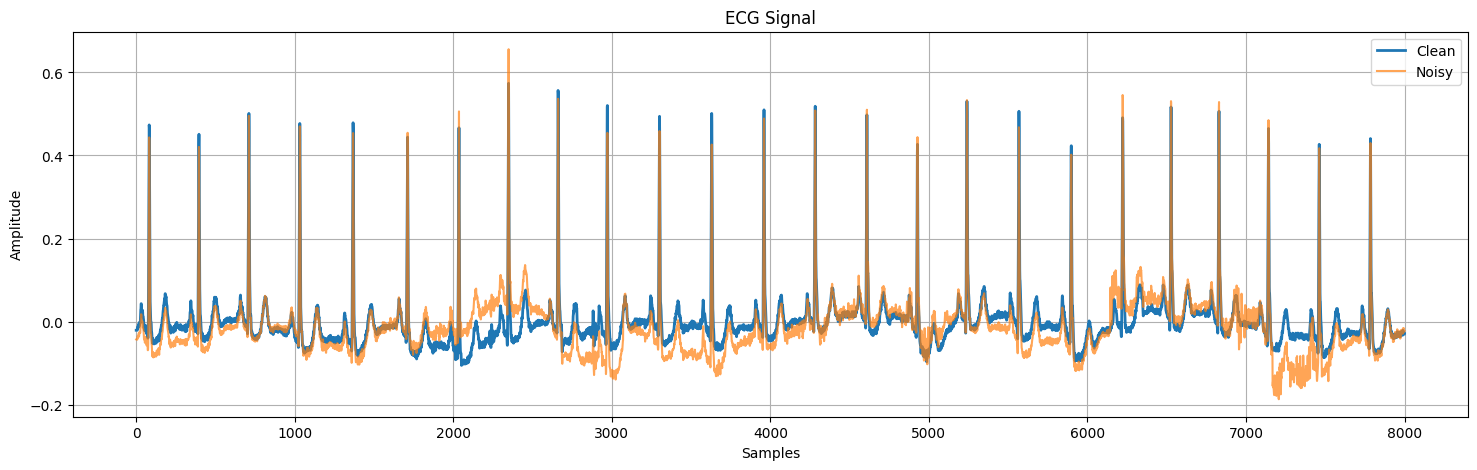

In [25]:
full_clean = reconstruct_patient_signal(
    y_train,
    train_metadata,
    '101'
)

full_noisy = reconstruct_patient_signal(
    x_train,
    train_metadata,
    '101'
)

plot_ecg(
    clean=full_clean,
    noisy=full_noisy,
    start=0,
    end=8000
)

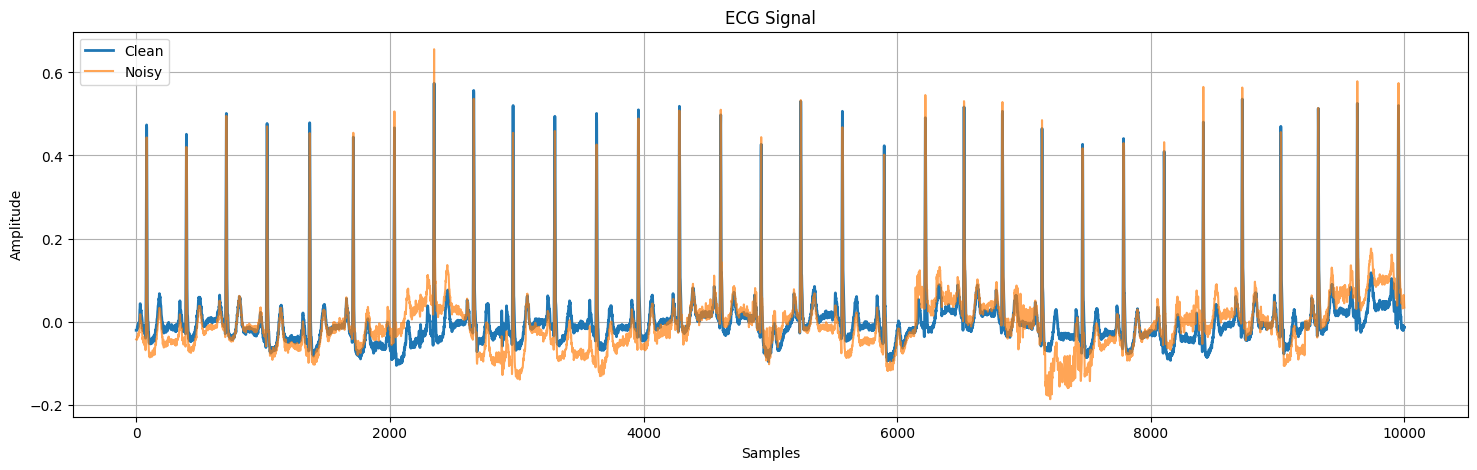

In [26]:
plot_ecg(
    clean=full_clean,
    noisy=full_noisy,
    start=0,
    end=10000
)

Patient Record: 101
Noise Type   : BW
Target SNR   : 10 dB
Actual SNR   : 10.00 dB


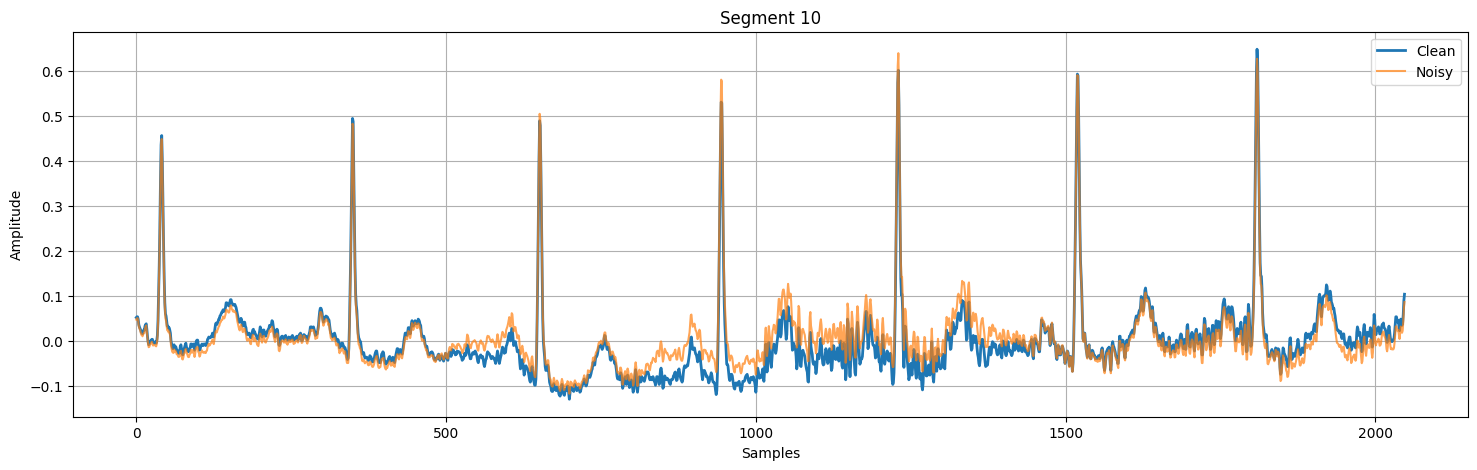

In [27]:
compare_segment(
    y_train,
    x_train,
    train_metadata,
    segment_index=10
)

Patient Record: 101
Noise Type   : MA
Target SNR   : 10 dB
Actual SNR   : 10.00 dB


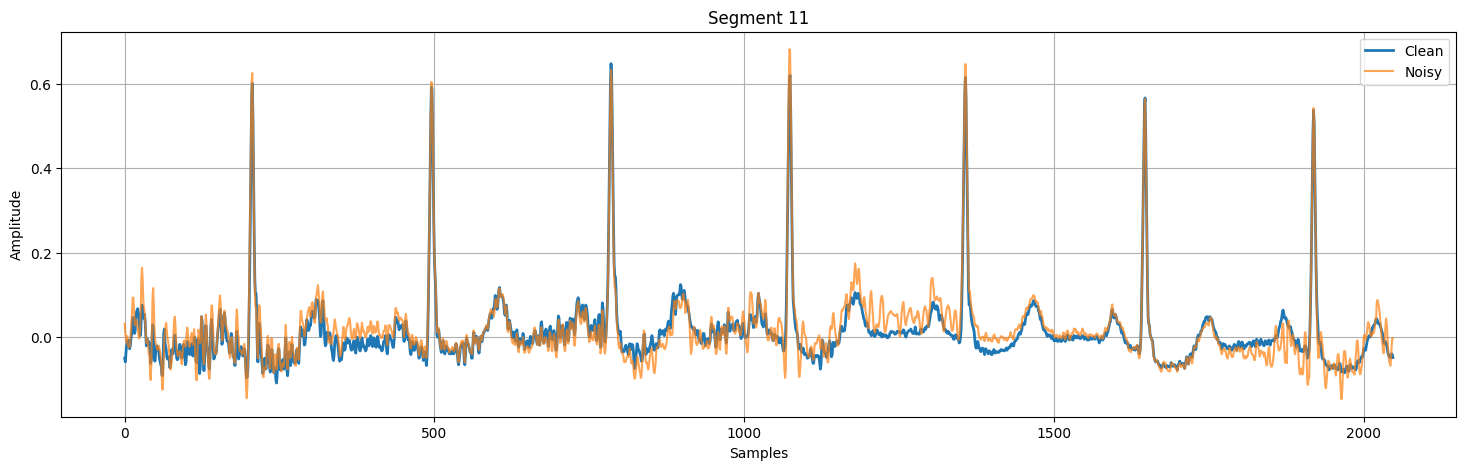

In [28]:
compare_segment(
    y_train,
    x_train,
    train_metadata,
    segment_index=11
)

In [ ]:

# i = random.choice(range(len(X_train_reload)))
# print(f"train segment idx: {i}")

# noisy = X_train_reload[i,0,:]   # noisy signal
# clean = Y_train_reload[i,0,:]   # clean signal

# plt.figure(figsize=(12,6))

# plt.subplot(2,1,1)
# plt.plot(clean)
# plt.title("Clean ECG")

# plt.subplot(2,1,2)
# plt.plot(noisy)
# plt.title("Noisy ECG")

# plt.tight_layout()
# plt.show()

In [ ]:
# i = random.choice(range(len(X_train_reload)))
# print(f"train segment idx: {i}")

# plt.figure(figsize=(15,5))

# plt.plot(X_train_reload[i,0,:], label='Noisy')
# plt.plot(Y_train_reload[i,0,:], label='Clean')

# plt.legend()
# plt.title("Noisy vs Clean ECG")

# plt.show()

In [ ]:
# i = random.choice(range(len(X_train_reload)))
# print(f"train segment idx: {i}")

# plt.figure(figsize=(15,5))

# plt.plot(X_train_reload[i,0,:], label='Noisy')
# plt.plot(Y_train_reload[i,0,:], label='Clean')

# plt.legend()
# plt.title("Noisy vs Clean ECG")

# plt.show()

In [ ]:
# X_train = np.load(os.path.join(SAVE_DIR, "X_train.npy"))
# Y_train = np.load(os.path.join(SAVE_DIR, "Y_train.npy"))

# X_test = np.load(os.path.join(SAVE_DIR, "X_test.npy"))
# Y_test = np.load(os.path.join(SAVE_DIR, "Y_test.npy"))

In [ ]:
# X_train.shape

In [ ]:
# ########### Autoencoder Architecture (simple) ###########

# class ECGAutoencoder(nn.Module):

#     def __init__(self):
#         super().__init__()

#         # Encoder
#         self.encoder = nn.Sequential(

#             nn.Conv1d(1, 16, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool1d(2),

#             nn.Conv1d(16, 32, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool1d(2),

#             nn.Conv1d(32, 64, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool1d(2)
#         )

#         # Decoder
#         self.decoder = nn.Sequential(

#             nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2),
#             nn.ReLU(),

#             nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2),
#             nn.ReLU(),

#             nn.ConvTranspose1d(16, 1, kernel_size=2, stride=2),

#             nn.Tanh()
#         )

#     def forward(self, x):

#         x = self.encoder(x)
#         x = self.decoder(x)

#         return x

In [ ]:
########### Autoencoder Architecture (advanced) ###########

In [ ]:
# ########### Denoising Loss Function ###########

# class PeakWeightedLoss(nn.Module):

#     def __init__(self):
#         super().__init__()

#     def forward(self, clean, denoised):

#         # ----------------------------------------------------
#         # Peak coefficient:
#         #
#         # Cp = 1 + abs(Xc - median(Xc))
#         # ----------------------------------------------------

#         median = torch.median(clean, dim=2, keepdim=True)[0]

#         Cp = 1 + torch.abs(clean - median)

#         # ----------------------------------------------------
#         # Improved weighted MSE
#         # ----------------------------------------------------

#         loss = ((clean - denoised) ** 2) * Cp

#         return torch.mean(loss)

In [ ]:
# ########### Training ###########
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# model = ECGAutoencoder().to(device)
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# X_train = torch.tensor(X_train, dtype=torch.float32)
# Y_train = torch.tensor(Y_train, dtype=torch.float32)

# train_loader = DataLoader(
#     TensorDataset(X_train, Y_train),
#     batch_size=64,
#     shuffle=True
# )

In [ ]:
# model = ECGAutoencoder()
# summary(model)

In [ ]:
# !pip install torch-summary



In [ ]:
# model = ECGAutoencoder()
# # Move to device if needed, then pass input shape (channels, length)
# summary(model)

In [ ]:
# train_loss =[]
# for epoch in range(N_ITERATIONS):
#     model.train()
#     total_loss = 0

#     for noisy, clean in train_loader:
#         noisy, clean = noisy.to(device), clean.to(device)

#         pred = model(noisy)
#         loss = criterion(pred, clean)

#         optimizer.zero_grad()
#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(
#             model.parameters(),
#             max_norm=1.0
#         )
#         optimizer.step()


#         total_loss += loss.item()
#     train_loss.append(total_loss)
#     print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

In [ ]:
# ########### Evaluation ###########

# def compute_snr(clean, denoised):
#     if isinstance(clean, torch.Tensor):
#         clean = clean.detach().cpu().numpy()
#     if isinstance(denoised, torch.Tensor):
#         denoised = denoised.detach().cpu().numpy()

#     noise = clean - denoised
#     signal_power = np.sum(clean ** 2)
#     noise_power = np.sum(noise ** 2)

#     if noise_power == 0:
#         return float("inf")  # Perfect reconstruction
#     return 10 * np.log10(signal_power / noise_power)

In [ ]:
# X_test  = torch.tensor(X_test,  dtype=torch.float32)
# Y_test  = torch.tensor(Y_test,  dtype=torch.float32)

# test_loader = DataLoader(
#     TensorDataset(X_test, Y_test),
#     batch_size=64,
#     shuffle=False
# )

In [ ]:
# model.eval()

# snr_noisy_list = []
# snr_denoised_list = []

# with torch.no_grad():
#     for noisy, clean in test_loader:
#         noisy = noisy.to(device)
#         clean = clean.numpy()

#         denoised = model(noisy).cpu().numpy()
#         noisy_np = noisy.cpu().numpy()

#         for i in range(len(clean)):
#             snr_noisy = compute_snr(clean[i,0], noisy_np[i,0])
#             snr_denoised = compute_snr(clean[i,0], denoised[i,0])

#             snr_noisy_list.append(snr_noisy)
#             snr_denoised_list.append(snr_denoised)

# print("Avg SNR (Noisy):", np.mean(snr_noisy_list))
# print("Avg SNR (Denoised):", np.mean(snr_denoised_list))
# print("Improvement:", np.mean(snr_denoised_list) - np.mean(snr_noisy_list))

In [ ]:
# model.eval()

# i = 100
# noisy = X_test[i:i+1].to(device)

# with torch.no_grad():
#     denoised = model(noisy).cpu().numpy()[0,0]

# clean = Y_test[i][0].numpy()
# noisy = X_test[i][0].numpy()

# plt.figure(figsize=(12,5))
# plt.plot(clean, label="Clean")
# # plt.plot(noisy, label="Noisy", alpha=0.6)
# plt.plot(denoised, label="Denoised", linewidth=2)
# plt.legend()
# plt.title("ECG Denoising")
# plt.show()

In [ ]:
# ########### Plotting Training error vs Validation error with epochs ###########

# plt.figure(figsize=(8,5))

# plt.plot(range(1, N_ITERATIONS+1), train_loss, marker='o')

# plt.title("Training Loss")

# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.grid(True)

# plt.show()

In [ ]:
########### Classification ###########